# Лабораторная работа №2
## *Корреляция между размером словаря и качеством модели*
по курсу Обработка естественного языка  
**направление:** Речевые технологии и машинное обучение  
**преподаватель:** Коротеева Олеся Владимировна
**выполнили:** Иванова Мария Кирилловна
**группа:** М4121

## Задача: выявить корреляцию (или ее отсутствие) между размером словаря токенизатора и качеством модели (выраженном в f1) для задачи сентимент-анализа.
Предлагаемый план работ:
1. Ознакомиться с документацией и реализовать LightningDataModule (https://lightning.ai/docs/pytorch/stable/data/datamodule.html)
 - Загрузить датасет
 - Провести предобработку
 - Выбрать токенизатор (BPE, WordPiece, Unigram)
 - Реализовать collate_fn функцию токенизации для даталодера - encode
 - Добавить даталодеры
2. Ознакомиться с документацией и реализовать LightningModule (https://lightning.ai/docs/pytorch/LTS/common/lightning_module.html)
 - Выбрать и реализовать подходящую архитектуру модели для сентимент-анализа текста
 - Написать прямой проход модели
 - Написать training_step, validation_step, test_step
3. Провести цикл обучений модели
 - Ознакомиться с документацией и выбрать оптимальные настройки для Trainer (https://lightning.ai/docs/pytorch/stable//common/trainer.html)
 - Зафиксировать все гиперпараметры и провести обучение-валидацию-тестирование для 5 значений размера словаря (выбранных на ваше усмотрение)
 - Полученные результаты представить в виде гистограммы или любой другой визуализации

In [ ]:
# Установка всех необходимых пакетов
!pip install lightning
!pip install datasets
!pip install tokenizers
!pip install torchmetrics
!pip install pandas
!pip install matplotlib
!pip install scikit-learn

In [2]:
import torch
import re
import datasets
from google.colab import files
import lightning.pytorch as pl
import tokenizers
from typing import *
import torchmetrics
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datasets import Dataset
from lightning.pytorch.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split

# Data

In [3]:
class MyDataModule(pl.LightningDataModule):
    def __init__(
        self,
        negative_file: str,
        positive_file: str,
        bs: int = 16,
        num_workers: int = 12,
        vocab_size: int = 5000,
        max_length: int = 256,
        test_size: float = 0.2,
        val_size: float = 0.1
    ):
        super().__init__()
        self.bs = bs
        self.num_workers = num_workers
        self.vocab_size = vocab_size
        self.max_length = max_length
        self.negative_file = negative_file
        self.positive_file = positive_file
        self.test_size = test_size
        self.val_size = val_size

    def prepare_data(self):
        pass

    def clean_text(self, text):
        text = str(text)
        text = text.lower()
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
        text = re.sub(r'@\w+', '', text)
        text = re.sub(r'[^\w\s]', '', text)
        text = re.sub(r'\s+', ' ', text).strip()
        return text

    def setup(self, stage=None):
        negative_df = pd.read_csv(
            self.negative_file,
            delimiter=";",
            header=None,
            names=["id", "tdate", "tname", "ttext", "ttype", "trep", "trtv", "tfav", "tstcount", "tfol", "tfrien", "listcount"],
            nrows=10000
        )

        positive_df = pd.read_csv(
            self.positive_file,
            delimiter=";",
            header=None,
            names=["id", "tdate", "tname", "ttext", "ttype", "trep", "trtv", "tfav", "tstcount", "tfol", "tfrien", "listcount"],
            nrows=10000
        )

        sentiment = pd.concat([negative_df, positive_df])[['ttext', 'ttype']]
        sentiment['ttext'] = sentiment['ttext'].apply(self.clean_text)
        sentiment = sentiment[sentiment['ttext'].str.len() > 0]
        sentiment.loc[sentiment.ttype < 0, 'ttype'] = 0

        self.label_dict = {0: 0, 1: 1}

        X = sentiment['ttext'].tolist()
        y = sentiment['ttype'].tolist()

        X_train, X_temp, y_train, y_temp = train_test_split(
            X, y,
            test_size=self.test_size + self.val_size,
            random_state=42,
            stratify=y
        )

        X_val, X_test, y_val, y_test = train_test_split(
            X_temp, y_temp,
            test_size=0.5,
            random_state=42,
            stratify=y_temp
        )

        train_ds = Dataset.from_dict({"text": X_train, "label": y_train})
        val_ds = Dataset.from_dict({"text": X_val, "label": y_val})
        test_ds = Dataset.from_dict({"text": X_test, "label": y_test})

        self.ds = datasets.DatasetDict({
            "train": train_ds,
            "val": val_ds,
            "test": test_ds
        })

        tokenizer = tokenizers.Tokenizer(tokenizers.models.BPE(unk_token="[UNK]"))
        trainer = tokenizers.trainers.BpeTrainer(
            vocab_size=self.vocab_size,
            special_tokens=["[UNK]", "[CLS]", "[SEP]", "[PAD]", "[MASK]"]
        )
        tokenizer.train_from_iterator(self.ds['train']['text'], trainer=trainer)

        tokenizer.enable_truncation(self.max_length)
        tokenizer.enable_padding(pad_token="[PAD]", direction="left")
        self.tokenizer = tokenizer

    def train_dataloader(self) -> torch.utils.data.DataLoader:
        return torch.utils.data.DataLoader(
            self.ds["train"],
            batch_size=self.bs,
            shuffle=True,
            collate_fn=self.encode,
            num_workers=self.num_workers
        )

    def val_dataloader(self) -> torch.utils.data.DataLoader:
        return torch.utils.data.DataLoader(
            self.ds["val"],
            batch_size=self.bs,
            shuffle=False,
            collate_fn=self.encode,
            num_workers=self.num_workers
        )

    def test_dataloader(self) -> torch.utils.data.DataLoader:
        return torch.utils.data.DataLoader(
            self.ds["test"],
            batch_size=self.bs,
            shuffle=False,
            collate_fn=self.encode,
            num_workers=self.num_workers
        )

    def encode(self, batch) -> Dict:
        input_ids = self.tokenizer.encode_batch([x["text"] for x in batch])
        input_ids = torch.tensor([x.ids for x in input_ids])
        label = torch.tensor([x["label"] for x in batch])
        return {"input_ids": input_ids, "label": label}

In [4]:
uploaded = files.upload()

Saving negative.csv to negative.csv
Saving positive.csv to positive.csv


In [5]:
dm = MyDataModule(
    negative_file='negative.csv',
    positive_file='positive.csv',
    vocab_size=1000
    )
test_texts = [
    "Смотри фильм!! https://example.com @user",
    "Я #счастлив сегодня!!! :)",
    "Почему? потому что...",
    "Цена 100$ & спецпредложение 50%",
    "Хороший - плохой (спорно)",
    "Привет!!! Как дела? :)"
]

print("до очистки:")
for text in test_texts:
    print(f"  {text}")

print("\nпосле очистки:")
for text in test_texts:
    cleaned = dm.clean_text(text)
    print(f"  {cleaned}")

до очистки:
  Смотри фильм!! https://example.com @user
  Я #счастлив сегодня!!! :)
  Почему? потому что...
  Цена 100$ & спецпредложение 50%
  Хороший - плохой (спорно)
  Привет!!! Как дела? :)

после очистки:
  смотри фильм
  я счастлив сегодня
  почему потому что
  цена 100 спецпредложение 50
  хороший плохой спорно
  привет как дела


# Model

In [6]:
class RNNModel(pl.LightningModule):
    def __init__(self, vocab_size, embd_size, hidden_size, output_size, dropout=0.3):
        super(RNNModel, self).__init__()
        self.save_hyperparameters()

        self.embedding = torch.nn.Embedding(vocab_size, embd_size)
        self.rnn = torch.nn.RNN(embd_size, hidden_size, batch_first=True, dropout=dropout)
        self.dropout = torch.nn.Dropout(dropout)
        self.fc = torch.nn.Linear(hidden_size, output_size)
        self.loss = torch.nn.CrossEntropyLoss()

        self.train_f1 = torchmetrics.F1Score(task="multiclass", num_classes=output_size)
        self.val_f1 = torchmetrics.F1Score(task="multiclass", num_classes=output_size)
        self.test_f1 = torchmetrics.F1Score(task="multiclass", num_classes=output_size)

    def forward(self, x):
        x = self.embedding(x)
        x, _ = self.rnn(x)
        x = self.dropout(x[:, -1, :])
        x = self.fc(x)
        return x

    def training_step(self, batch, batch_idx):
        x, y = batch["input_ids"], batch["label"]
        logits = self(x)
        loss = self.loss(logits, y)

        preds = torch.argmax(logits, dim=1)
        self.train_f1(preds, y)

        self.log('train_loss', loss, prog_bar=True)
        self.log('train_f1', self.train_f1, on_step=False, on_epoch=True, prog_bar=True)

        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch["input_ids"], batch["label"]
        logits = self(x)
        loss = self.loss(logits, y)

        preds = torch.argmax(logits, dim=1)
        self.val_f1(preds, y)

        self.log('val_loss', loss, prog_bar=True)
        self.log('val_f1', self.val_f1, on_step=False, on_epoch=True, prog_bar=True)

        return loss

    def test_step(self, batch, batch_idx):
        x, y = batch["input_ids"], batch["label"]
        logits = self(x)
        loss = self.loss(logits, y)

        preds = torch.argmax(logits, dim=1)
        self.test_f1(preds, y)

        self.log('test_loss', loss)
        self.log('test_f1', self.test_f1, on_step=False, on_epoch=True)

        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=0.0005, weight_decay=1e-5)

# Training

In [23]:
negative_file = 'negative.csv'
positive_file = 'positive.csv'

MAX_LENGTH = 256
EMBD_SIZE = 128
HIDDEN_SIZE = 128
BATCH_SIZE = 16
MAX_EPOCHS = 5

VOCAB_SIZES = [1000, 3000, 5000, 10000, 20000]

results = []

for vocab_size in VOCAB_SIZES:
    print(f"Эксперимент {vocab_size}\n")

    dm = MyDataModule(
        negative_file=negative_file,
        positive_file=positive_file,
        bs=BATCH_SIZE,
        vocab_size=vocab_size,
        max_length=MAX_LENGTH
    )

    dm.setup()

    real_vocab_size = dm.tokenizer.get_vocab_size()
    print(f"Реальный размер словаря: {real_vocab_size}")

    model = RNNModel(
        vocab_size=real_vocab_size,
        embd_size=EMBD_SIZE,
        hidden_size=HIDDEN_SIZE,
        output_size=len(dm.label_dict)
    )

    early_stop = EarlyStopping(
        monitor="val_f1",
        mode="max",
        patience=2,
        verbose=True
    )

    trainer = pl.Trainer(
        max_epochs=MAX_EPOCHS,
        callbacks=[early_stop],
        accelerator="auto",
        devices=1,
        enable_progress_bar=True
    )

    trainer.fit(model, dm)

    test_result = trainer.test(model, dm)[0]

    results.append({
        "vocab_size": vocab_size,
        "real_vocab_size": real_vocab_size,
        "test_f1": test_result["test_f1"],
        "test_loss": test_result["test_loss"]
    })

    print(f"F1: {test_result['test_f1']:.4f}, Loss: {test_result['test_loss']:.4f}")

Эксперимент 1000



/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:641: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  super().__init__(mode, *args, **kwargs)
INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to

Реальный размер словаря: 1000


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ embedding │ Embedding         │  128 K │ train │     0 │
│ 1 │ rnn       │ RNN               │ 33.0 K │ train │     0 │
│ 2 │ dropout   │ Dropout           │      0 │ train │     0 │
│ 3 │ fc        │ Linear            │    258 │ train │     0 │
│ 4 │ loss      │ CrossEntropyLoss  │      0 │ train │     0 │
│ 5 │ train_f1  │ MulticlassF1Score │      0 │ train │     0 │
│ 6 │ val_f1    │ MulticlassF1Score │      0 │ train │     0 │
│ 7 │ test_f1   │ MulticlassF1Score │      0 │ train │     0 │
└───┴───────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 161 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 161 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 8                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

INFO: Metric val_f1 improved. New best score: 0.573
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_f1 improved. New best score: 0.573
INFO: Metric val_f1 improved by 0.005 >= min_delta = 0.0. New best score: 0.578
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_f1 improved by 0.005 >= min_delta = 0.0. New best score: 0.578
INFO: Metric val_f1 improved by 0.035 >= min_delta = 0.0. New best score: 0.613
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_f1 improved by 0.035 >= min_delta = 0.0. New best score: 0.613
INFO: Metric val_f1 improved by 0.017 >= min_delta = 0.0. New best score: 0.630
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_f1 improved by 0.017 >= min_delta = 0.0. New best score: 0.630
INFO: Metric val_f1 improved by 0.000 >= min_delta = 0.0. New best score: 0.630
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_f1 improved by 0.000 >= min_delta = 0.0. New best score: 0.630
INFO: `Trainer.fit` stopped: `max_epochs=5` re

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 12 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 12 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation migh

Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│          test_f1          │    0.6511163115501404     │
│         test_loss         │    0.7899967432022095     │
└───────────────────────────┴───────────────────────────┘

F1: 0.6511, Loss: 0.7900


# Визуализация результатов

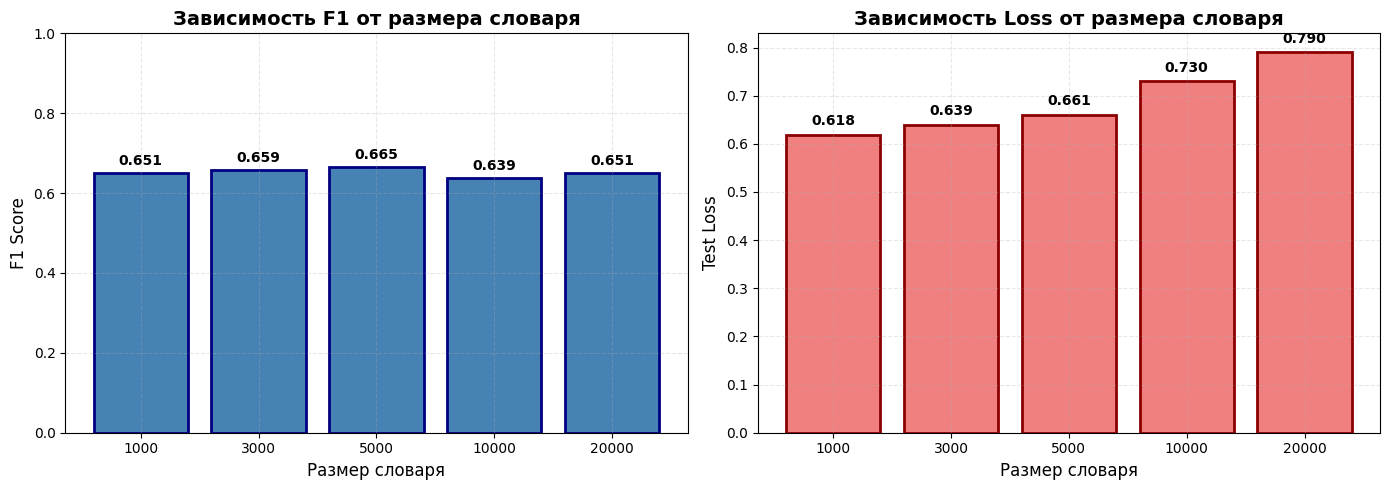

In [26]:
vocab_sizes = [r["vocab_size"] for r in results]
f1_scores = [r["test_f1"] for r in results]
losses = [r["test_loss"] for r in results]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма F1
bars1 = ax1.bar(range(len(vocab_sizes)), f1_scores, color='steelblue', edgecolor='navy', linewidth=2)
ax1.set_xlabel('Размер словаря', fontsize=12)
ax1.set_ylabel('F1 Score', fontsize=12)
ax1.set_title('Зависимость F1 от размера словаря', fontsize=14, fontweight='bold')
ax1.set_xticks(range(len(vocab_sizes)))
ax1.set_xticklabels([str(v) for v in vocab_sizes])
ax1.set_ylim([0, 1])
ax1.grid(True, alpha=0.3, linestyle='--')

for i, (bar, f1) in enumerate(zip(bars1, f1_scores)):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{f1:.3f}', ha='center', fontsize=10, fontweight='bold')

# Гистограмма Loss
bars2 = ax2.bar(range(len(vocab_sizes)), losses, color='lightcoral', edgecolor='darkred', linewidth=2)
ax2.set_xlabel('Размер словаря', fontsize=12)
ax2.set_ylabel('Test Loss', fontsize=12)
ax2.set_title('Зависимость Loss от размера словаря', fontsize=14, fontweight='bold')
ax2.set_xticks(range(len(vocab_sizes)))
ax2.set_xticklabels([str(v) for v in vocab_sizes])
ax2.grid(True, alpha=0.3, linestyle='--')

for i, (bar, loss) in enumerate(zip(bars2, losses)):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{loss:.3f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Проверка на словаре малого размера

In [7]:
negative_file = 'negative.csv'
positive_file = 'positive.csv'

MAX_LENGTH = 256
EMBD_SIZE = 128
HIDDEN_SIZE = 128
BATCH_SIZE = 16
MAX_EPOCHS = 5

VOCAB_SIZES = [10, 100, 500]

results = []

for vocab_size in VOCAB_SIZES:
    print(f"Эксперимент {vocab_size}\n")

    dm = MyDataModule(
        negative_file=negative_file,
        positive_file=positive_file,
        bs=BATCH_SIZE,
        vocab_size=vocab_size,
        max_length=MAX_LENGTH
    )

    dm.setup()

    real_vocab_size = dm.tokenizer.get_vocab_size()
    print(f"Реальный размер словаря: {real_vocab_size}")

    model = RNNModel(
        vocab_size=real_vocab_size,
        embd_size=EMBD_SIZE,
        hidden_size=HIDDEN_SIZE,
        output_size=len(dm.label_dict)
    )

    early_stop = EarlyStopping(
        monitor="val_f1",
        mode="max",
        patience=2,
        verbose=True
    )

    trainer = pl.Trainer(
        max_epochs=MAX_EPOCHS,
        callbacks=[early_stop],
        accelerator="auto",
        devices=1,
        enable_progress_bar=True
    )

    trainer.fit(model, dm)

    test_result = trainer.test(model, dm)[0]

    results.append({
        "vocab_size": vocab_size,
        "real_vocab_size": real_vocab_size,
        "test_f1": test_result["test_f1"],
        "test_loss": test_result["test_loss"]
    })

    print(f"F1: {test_result['test_f1']:.4f}, Loss: {test_result['test_loss']:.4f}")

Эксперимент 10



/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:641: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  super().__init__(mode, *args, **kwargs)
INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to

Реальный размер словаря: 109


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ embedding │ Embedding         │ 14.0 K │ train │     0 │
│ 1 │ rnn       │ RNN               │ 33.0 K │ train │     0 │
│ 2 │ dropout   │ Dropout           │      0 │ train │     0 │
│ 3 │ fc        │ Linear            │    258 │ train │     0 │
│ 4 │ loss      │ CrossEntropyLoss  │      0 │ train │     0 │
│ 5 │ train_f1  │ MulticlassF1Score │      0 │ train │     0 │
│ 6 │ val_f1    │ MulticlassF1Score │      0 │ train │     0 │
│ 7 │ test_f1   │ MulticlassF1Score │      0 │ train │     0 │
└───┴───────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 47.2 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 47.2 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 8                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

INFO: Metric val_f1 improved. New best score: 0.599
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_f1 improved. New best score: 0.599
INFO: Metric val_f1 improved by 0.023 >= min_delta = 0.0. New best score: 0.622
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_f1 improved by 0.023 >= min_delta = 0.0. New best score: 0.622
INFO: Metric val_f1 improved by 0.020 >= min_delta = 0.0. New best score: 0.642
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_f1 improved by 0.020 >= min_delta = 0.0. New best score: 0.642
INFO: Metric val_f1 improved by 0.003 >= min_delta = 0.0. New best score: 0.645
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_f1 improved by 0.003 >= min_delta = 0.0. New best score: 0.645
INFO: `Trainer.fit` stopped: `max_epochs=5` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=5` reached.


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 12 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 12 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation migh

Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│          test_f1          │    0.6497834324836731     │
│         test_loss         │    0.6265325546264648     │
└───────────────────────────┴───────────────────────────┘

F1: 0.6498, Loss: 0.6265


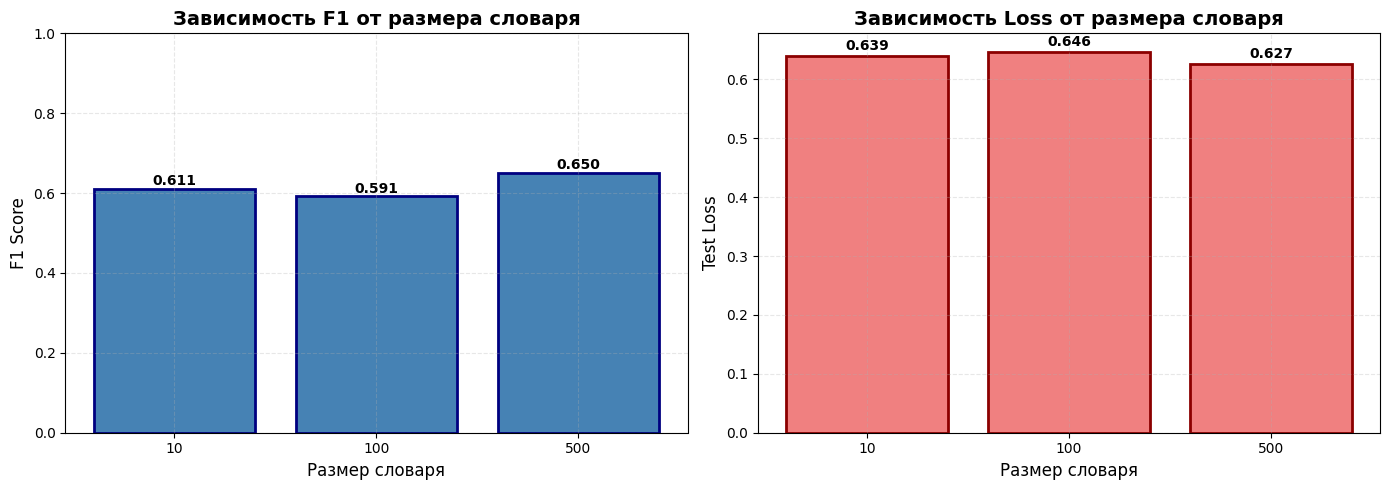

In [9]:
vocab_sizes = [r["vocab_size"] for r in results]
f1_scores = [r["test_f1"] for r in results]
losses = [r["test_loss"] for r in results]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма F1
bars1 = ax1.bar(range(len(vocab_sizes)), f1_scores, color='steelblue', edgecolor='navy', linewidth=2)
ax1.set_xlabel('Размер словаря', fontsize=12)
ax1.set_ylabel('F1 Score', fontsize=12)
ax1.set_title('Зависимость F1 от размера словаря', fontsize=14, fontweight='bold')
ax1.set_xticks(range(len(vocab_sizes)))
ax1.set_xticklabels([str(v) for v in vocab_sizes])
ax1.set_ylim([0, 1])
ax1.grid(True, alpha=0.3, linestyle='--')

for i, (bar, f1) in enumerate(zip(bars1, f1_scores)):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0,
             f'{f1:.3f}', ha='center', fontsize=10, fontweight='bold')

# Гистограмма Loss
bars2 = ax2.bar(range(len(vocab_sizes)), losses, color='lightcoral', edgecolor='darkred', linewidth=2)
ax2.set_xlabel('Размер словаря', fontsize=12)
ax2.set_ylabel('Test Loss', fontsize=12)
ax2.set_title('Зависимость Loss от размера словаря', fontsize=14, fontweight='bold')
ax2.set_xticks(range(len(vocab_sizes)))
ax2.set_xticklabels([str(v) for v in vocab_sizes])
ax2.grid(True, alpha=0.3, linestyle='--')

for i, (bar, loss) in enumerate(zip(bars2, losses)):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{loss:.3f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Вывод
В ходе лабораторной работы было изучено влияние размера словаря BPE-токенизатора на качество модели сентимент-анализа. Было обучено 5 моделей с размерами словаря: 1000, 3000, 5000, 10000 и 20000 токенов.

### Результаты экспериментов:
- **F1-мера** возрастала с 0.65 до 0.66 при увеличении словаря с 1000 до 5000 токенов, и незначительно снизилась (приблизительно на 1%).
- **Значение Loss** росло с увеличением словаря, что объяснимо, поскольку при возрастании количества токенов модель переобучалась на редких токенах.

### Итог:
На данном датасете оптимальным оказался размер словаря **5000 токенов**, обеспечивающий баланс между богатством словаря и качеством классификации.

Таким образом, корреляция между размером словаря и качеством модели **существует** — после достижения оптимума дальнейшее расширение словаря может приводить к ухудшению метрик из-за лишних шумовых токенов.